# Intro to Pandas

## External Resources
- [https://pandas.pydata.org/](https://pandas.pydata.org/)
- Documentation - [https://pandas.pydata.org/docs/](https://pandas.pydata.org/docs/)
- YouTube Video - [https://youtu.be/k7ZFDMhFcuA](https://youtu.be/k7ZFDMhFcuA)
- YouTube Podcast - [https://youtu.be/je3c5_xkWjw](https://youtu.be/je3c5_xkWjw)
- NotebookLM learning materials - [https://notebooklm.google.com/notebook/3814adae-d893-430f-9548-4b2983e6d13e](https://notebooklm.google.com/notebook/3814adae-d893-430f-9548-4b2983e6d13e)

## Overview
- a fast, powerful, flexible and easy to use open source data analysis and manipulation tool built on Python

## What kind of data does pandas handle?

### pandas data table representation
![img](images/Pandas-Table.svg)
- to work with pandas package, must first import the package
- to install/update pandas you can use either conda or pip

```bash
conda install pandas
pip install pandas
```

In [94]:
import pandas as pd
import numpy as np

In [95]:
print(f'pandas version: {pd.__version__}')
print(f'numpy version: {np.__version__}')

pandas version: 3.0.0
numpy version: 2.3.5


## Series

- series is 1-d labeled array capable of holding any data type (integers, strings, float, Python objects, etc.)
- the axis labels collectively referred to as the **index**
- API to create Series:
```python
s = pd.Series(data, index=index)
```

- data can be:
    - NumPy's **ndarray**
    - Python dictionary
    - a scalar value (e.g. 5)
    - Python List
- index is a list of axis labels
    - index can be thought as row id or sample id
- if data is an ndarray, index must be the same length as data
    - if no index is passed, default index will be created `[0, ..., len(data)-1]`
- each column in the DataFrame is a Series

In [96]:
s = pd.Series(np.random.randn(5))

In [97]:
s

0   -0.532407
1    1.807653
2   -0.344842
3   -1.419849
4    1.562077
dtype: float64

In [98]:
s.index

RangeIndex(start=0, stop=5, step=1)

In [99]:
s1 = pd.Series(np.random.randn(5), index=['a', 'b', 'c', 'd', 'e'])

In [100]:
s1

a   -0.382519
b    1.274873
c   -1.292278
d   -1.120049
e    0.198392
dtype: float64

In [101]:
s1.index

Index(['a', 'b', 'c', 'd', 'e'], dtype='str')

In [102]:
# from dict
d = {"b": 1, "a": 0, "c": 2}
s2 = pd.Series(d)

In [103]:
s2

b    1
a    0
c    2
dtype: int64

In [104]:
# scalar value is repeated to match the length of index
s3 = pd.Series(5.0, index=["a", "b", "c", "d", "e"])

In [105]:
s3

a    5.0
b    5.0
c    5.0
d    5.0
e    5.0
dtype: float64

In [106]:
# creating Series from Python List
s4 = pd.Series([1, 3, 5, np.nan, 6, 8])

In [107]:
s4

0    1.0
1    3.0
2    5.0
3    NaN
4    6.0
5    8.0
dtype: float64

### Series is ndarray-like
- Series acts very similar to a ndarray, and is a valid argument to most NumPy functions
- slicing Series also slices the index

In [108]:
s1

a   -0.382519
b    1.274873
c   -1.292278
d   -1.120049
e    0.198392
dtype: float64

In [109]:
s1[0]

KeyError: 0

In [ ]:
s1[3:]

In [ ]:
# slice using condition
s1[s1 > s1.median()]

In [ ]:
# slice using indices
s1[[4, 3, 1]]

In [ ]:
# calculate the exponential (2*n) of each element n in the ndarray
# https://numpy.org/doc/stable/reference/generated/numpy.exp.html?highlight=exp#numpy.exp
np.exp2(s3)

In [ ]:
s3.dtype

### extract data array from Series
- extract just data as array without index

In [ ]:
s3.array

### convert series to ndarray

In [ ]:
ndarr = s3.to_numpy()

In [ ]:
ndarr

In [ ]:
type(ndarr)

In [ ]:
ndarr.size

In [ ]:
ndarr.shape

### Series is dict-like
- use index as the key to get the corresponding value

In [ ]:
s1['a']

In [ ]:
s3['e']

In [ ]:
s3['e'] = 15.0

In [ ]:
s3

In [ ]:
s3['g']

In [ ]:
# use get with default value if key is missing
s3.get('g', np.nan)

### Vectorized operations and label alignment with Series
- very similar to NumPy ndarray

In [ ]:
s3

In [ ]:
s3+s3

In [ ]:
s3-s3

In [ ]:
s3*2

In [ ]:
s3/5

In [ ]:
# Series automatically aligns the data based on label
# if the label is not found in one Series or the other, the result will be marked as missing NaN
s3[1:] + s3[:-1]

### Name attribute
- Series can also have a **name** atribute

In [ ]:
s4 = pd.Series(np.random.randn(5), name="Some Name")

In [ ]:
s4.name

In [ ]:
s4

In [ ]:
# Series.rename creates a new Series with new name
s5 = s4.rename('New Name')

In [ ]:
s5

## DataFrame
- data table in pandas is called DataFrame
- DataFrame is the primary data structure of pandas
- Python dict can be used create DataFrame where keys will be used as column headers and the list of values as columns of the DataFrame
- each column of DataFrame is called `Series`

In [ ]:
aDict = {
    "Name": [
            "Braund, Mr. Owen Harris",
            "Allen, Mr. William Henry",
            "Bonnell, Miss. Elizabeth"
    ],
    "Age": [22, 35, 58],
    "Sex": ["male", "male", "female"]
}

In [ ]:
df = pd.DataFrame(aDict)

In [ ]:
df

In [ ]:
df2 = pd.DataFrame(
{
    "A": 1.0,
    "B": pd.Timestamp("20130102"),
    "C": pd.Series(1, index=list(range(4)), dtype="float32"),
    "D": np.array([3] * 4, dtype="int32"),
    "E": pd.Categorical(["test", "train", "test", "train"]),
    "F": "foo",
})

In [ ]:
df2

### spreadsheet data
- the above df can be represented in a spreadsheet software
![SpreadSheet](./images/01_table_spreadsheet.png)

In [ ]:
df

In [ ]:
# just work with the data in column - Age
# use dictionary syntax
df["Age"]

In [ ]:
# access series/column as attribute
df.Age

## DataFrame Complete Reference
- complete reference: https://pandas.pydata.org/pandas-docs/stable/reference/frame.html

## DataFrame utility methods and attributes to review data
- `df.columns` - return the column labels of the DataFrame
- `df.index` - return the index (row labels/ids) of the DataFrame df object
- `df.dtypes` - return Series with the data type of each column in the df object
- `df.values` - return a **NumPy** representation of the DataFrame df object
- `df.axes` - return a list representing the axes of the DataFrame, `[row labels]` and `[column labels]`
- `df.shape` - return a tuple representing the dimensionality of the DataFrame df object
- `df.size` - return an int representing the number of elements in the DataFrame df object
- `df.info()` - print a concise summary of a DataFrame df object
- `df.describe()` - generate descriptive statistics
- `df.head(n)` - display the first n rows in the DataFarme df object; default n=5
- `df.tail(n)` - display the last n rows in the DataFrame df object; default n=5

In [ ]:
df.columns

In [ ]:
df.index

In [ ]:
df.values

In [ ]:
df.dtypes

In [ ]:
df.axes

In [ ]:
df.shape

In [ ]:
df.size

In [ ]:
# generate descriptive statistics
df.describe()

In [ ]:
# print first 2 rows
df.head(2)

In [ ]:
# get individual stats for each Searies
df['Age'].max()

In [ ]:
# print last 2 rows
df.tail(2)

## Read and write tabular data

![](./images/02_io_readwrite1.svg)

- use pandas `.read_*(fileName)` to read data from various formats
- Pandas raw data: [https://github.com/pandas-dev/pandas/tree/master/doc/data](https://github.com/pandas-dev/pandas/tree/master/doc/data)
- read_csv - https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.read_csv.html

In [ ]:
# read CSV file directly from the Internet
iris_df = pd.read_csv('https://raw.githubusercontent.com/pandas-dev/pandas/master/doc/data/iris.data')

In [ ]:
iris_df.head()

,SepalLength,SepalWidth,PetalLength,PetalWidth,Name
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [ ]:
iris_df.tail()

,SepalLength,SepalWidth,PetalLength,PetalWidth,Name
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica
149,5.9,3.0,5.1,1.8,Iris-virginica


In [ ]:
# technical summary of DataFrame
iris_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   SepalLength  150 non-null    float64
 1   SepalWidth   150 non-null    float64
 2   PetalLength  150 non-null    float64
 3   PetalWidth   150 non-null    float64
 4   Name         150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 7.9 KB


In [ ]:
# statistical summary of iris dataset
iris_df.describe()

### Titanic Dataset

- https://github.com/pandas-dev/pandas/blob/master/doc/data/titanic.csv
- https://www.openml.org/d/40945
- manually download titanic.csv or use wget/curl to download the file

```bash
wget https://raw.githubusercontent.com/pandas-dev/pandas/master/doc/data/titanic.csv
curl https://raw.githubusercontent.com/pandas-dev/pandas/master/doc/data/titanic.csv -o data/titanic.csv
```

#### Column name description

```
PassengerId: Id of every passenger.

Survived: This feature have value 0 and 1. 0 for not survived and 1 for survived.

Pclass: Passenger class: 3 classes: Class 1, Class 2 and Class 3.

Name: Name of passenger.

Sex: Gender of passenger.

Age: Age of passenger.

SibSp: Indication that passenger have siblings and spouse.

Parch: Whether a passenger is alone or have family.

Ticket: Ticket number of passenger.

Fare: Indicating the fare.

Cabin: The cabin of passenger.

Embarked: The embarked category.
```

In [ ]:
%%bash
mkdir -p data
curl https://raw.githubusercontent.com/pandas-dev/pandas/master/doc/data/titanic.csv -o data/titanic.csv

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 60080  100 60080    0     0  1051k      0 --:--:-- --:--:-- --:--:--     0:--:-- --:--:-- 1066k


In [ ]:
# let's read titanic.csv file as DataFrame
titanicDf = pd.read_csv('data/titanic.csv')

In [ ]:
titanicDf
# notice the dataset already provides PassengerId as index column
# read_csv automatically adds the index column or row id

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [ ]:
# let's read the csv with PassengerId as index column (row_id)
titanicDf = pd.read_csv('data/titanic.csv', index_col="PassengerId")

In [ ]:
# print first 8 rows
titanicDf.head(8)

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
8,0,3,"Palsson, Master Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S


In [ ]:
titanicDf.shape

(891, 11)

In [ ]:
titanicDf.dtypes

Survived      int64
Pclass        int64
Name            str
Sex             str
Age         float64
SibSp         int64
Parch         int64
Ticket          str
Fare        float64
Cabin           str
Embarked        str
dtype: object

## Sort table rows
- based on some column name
- https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.sort_values.html

```python
DataFrame.sort_values(by='columnName', axis=0, ascending=True, inplace=False, kind='quicksort', na_position='last', ignore_index=False, key=None)
```

- returns the sorted DataFrame (NOT an inplace sort by default)

In [ ]:
sortedTitanicDf = titanicDf.sort_values(by='Age')

In [110]:
sortedTitanicDf

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
804,1,3,"Thomas, Master Assad Alexander",male,0.42,0,1,2625,8.5167,NaN,C
756,1,2,"Hamalainen, Master Viljo",male,0.67,1,1,250649,14.5000,NaN,S
645,1,3,"Baclini, Miss Eugenie",female,0.75,2,1,2666,19.2583,NaN,C
470,1,3,"Baclini, Miss Helene Barbara",female,0.75,2,1,2666,19.2583,NaN,C
79,1,2,"Caldwell, Master Alden Gates",male,0.83,0,2,248738,29.0000,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
860,0,3,"Razi, Mr. Raihed",male,NaN,0,0,2629,7.2292,NaN,C
864,0,3,"Sage, Miss Dorothy Edith ""Dolly""",female,NaN,8,2,CA. 2343,69.5500,NaN,S
869,0,3,"van Melkebeke, Mr. Philemon",male,NaN,0,0,345777,9.5000,NaN,S


In [ ]:
# sorting by default returns sorted DF without sorting original DF in place
titanicDf.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
# sort using multiple columns and in descending order
titanicDf.sort_values(by=['Pclass', 'Age'], ascending=False).head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
852,0,3,"Svensson, Mr. Johan",male,74.0,0,0,347060,7.7750,NaN,S
117,0,3,"Connors, Mr. Patrick",male,70.5,0,0,370369,7.7500,NaN,Q
281,0,3,"Duane, Mr. Frank",male,65.0,0,0,336439,7.7500,NaN,Q
484,1,3,"Turkula, Mrs. (Hedwig)",female,63.0,0,0,4134,9.5875,NaN,S
327,0,3,"Nysveen, Mr. Johan Hansen",male,61.0,0,0,345364,6.2375,NaN,S


### Write the DataFrame as Excel file

- install openpyxl library from Terminal; doesn't seem to work from notebook
- use pip or conda to install openpyxl
- conda is installed on Codespaces

```bash
conda activate ml
conda install -y openpyxl
```

```bash
pip install openpyxl
```

In [ ]:
! conda install -y openpyxl

Retrieving notices: done
Channels:
 - 
Platform: linux-64
Solving environment: failed

PackagesNotFoundError: The following packages are missing from the target environment:

  - openpyxl




In [ ]:
sortedTitanicDf.to_excel('data/titanic_sorted_age.xlsx', sheet_name='passengers')

In [ ]:
# technical summary of DataFrame
sortedTitanicDf.info()

<class 'pandas.DataFrame'>
Index: 891 entries, 804 to 889
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    str    
 3   Sex       891 non-null    str    
 4   Age       714 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    str    
 8   Fare      891 non-null    float64
 9   Cabin     204 non-null    str    
 10  Embarked  889 non-null    str    
dtypes: float64(2), int64(4), str(5)
memory usage: 118.9 KB


## Select a subset of a DataFrame

### Select specific columns
![](./images/03_subset_columns.svg)

In [ ]:
# copy just the Age column or Series
ages = titanicDf["Age"]

In [ ]:
type(ages)

pandas.Series

In [ ]:
ages.shape

(891,)

In [ ]:
# get age and sex columns
age_sex = titanicDf[['Age', 'Sex']]

In [ ]:
type(age_sex)

pandas.DataFrame

In [ ]:
age_sex.head()

,Age,Sex
PassengerId,,
1,22.0,male
2,38.0,female
3,26.0,female
4,35.0,female
5,35.0,male


In [ ]:
age_sex.shape

(891, 2)

In [ ]:
# boolen mask of passengers older than 35; returns True or False based on condition
titanicDf['Age'] > 35

PassengerId
1      False
2       True
3      False
4      False
5      False
       ...  
887    False
888    False
889    False
890    False
891    False
Name: Age, Length: 891, dtype: bool

In [111]:
# DF of passengers older than 35
# passengers older than 35; returns True or False based on condition
titanicDf[titanicDf['Age'] < 2]

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
79,1,2,anonymous,male,0.83,0,2,248738,29.0000,NaN,S
165,0,3,anonymous,male,1.00,4,1,3101295,39.6875,NaN,S
173,1,3,anonymous,female,1.00,1,1,347742,11.1333,NaN,S
184,1,2,anonymous,male,1.00,2,1,230136,39.0000,F4,S
306,1,1,anonymous,male,0.92,1,2,113781,151.5500,C22 C26,S
382,1,3,anonymous,female,1.00,0,2,2653,15.7417,NaN,C
387,0,3,anonymous,male,1.00,5,2,CA 2144,46.9000,NaN,S
470,1,3,anonymous,female,0.75,2,1,2666,19.2583,NaN,C
645,1,3,anonymous,female,0.75,2,1,2666,19.2583,NaN,C


## Select specific rows and columns
- create new DataFrame using the filtered rows and columns

- two ways:

### df.iloc selections
- use row ids and column ids
```python
df.iloc[[row selection], [column selection]]
```
- row selection can be:
    - single row index values: `[100]`
    - integer list of row indices: `[0, 2, 10]`
    - slice of row indices: `[2:10]`
        
- column selection can be:
    - single column selection: `[10]`
    - integer list of col indices: `[0, 3, 5]`
    - slice of column indices: `[3:10]`
    

### df.loc selection
- use row labels column labels

```python
df.loc[[row selection], [column selection]]
```
- row selection:
    - single row label/index: `["john"]`
    - list of row labels: `["john", "sarah"]`
    - condition: `[data['age'] >= 35]`
- column selection:
    - single column name name: `['Age']`
    - list of column names: `['Name, 'Age', 'Sex']`
    - slice of column names: `['Name':'Age']`
    
    
### Select specific rows and all the columns
![](images/03_subset_rows.svg)

In [ ]:
# Create new DataFrame based on the criteria
# similar to using where clause in SQL
passengers = titanicDf[titanicDf['Age']>35]

In [ ]:
passengers.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
2,1,1,anonymous,female,38.0,1,0,PC 17599,71.2833,C85,C
7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
12,1,1,"Bonnell, Miss Elizabeth",female,58.0,0,0,113783,26.5500,C103,S
14,0,3,"Andersson, Mr. Anders Johan",male,39.0,1,5,347082,31.2750,NaN,S
16,1,2,"Hewlett, Mrs. (Mary D Kingcome)",female,55.0,0,0,248706,16.0000,NaN,S


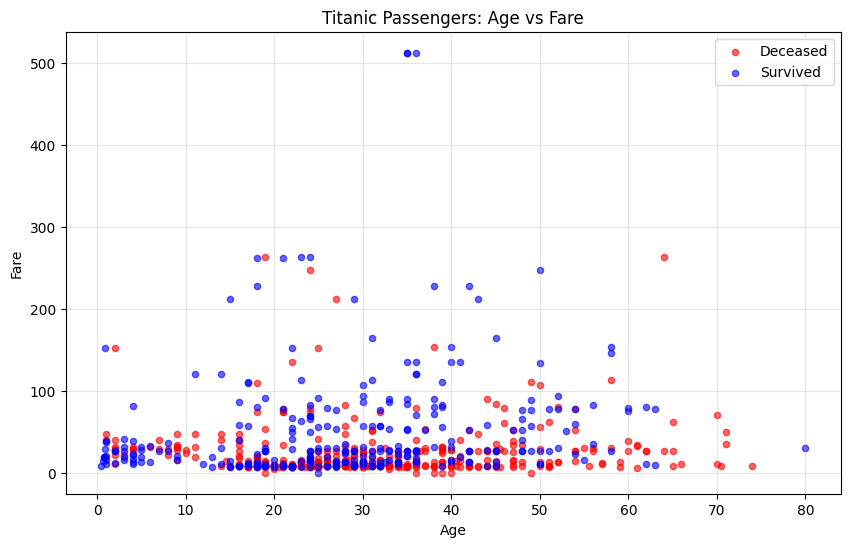

Survived
1    233
0     81
Name: count, dtype: int64

In [116]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10,6))
titanicDf[titanicDf['Survived'] == 0].plot.scatter(
    x='Age', 
    y='Fare', 
    color='red', 
    label='Deceased', 
    ax=ax, 
    alpha=0.6
)
titanicDf[titanicDf['Survived'] == 1].plot.scatter(
    x='Age', 
    y='Fare', 
    color='blue', 
    label='Survived', 
    ax=ax, 
    alpha=0.6
)
plt.title('Titanic Passengers: Age vs Fare')
plt.grid(True, alpha=0.3)
plt.show()

titanicDf[titanicDf['Sex'] == 'female']['Survived'].value_counts()

In [ ]:
passengers.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,217.000000,217.000000,217.000000,217.000000,217.000000,217.000000
mean,0.382488,1.811060,46.979263,0.345622,0.465438,43.966821
std,0.487119,0.858653,9.188272,0.522983,1.075809,56.083306
min,0.000000,1.000000,36.000000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,40.000000,0.000000,0.000000,12.525000
50%,0.000000,2.000000,45.000000,0.000000,0.000000,26.387500
75%,1.000000,3.000000,52.000000,1.000000,0.000000,55.900000
max,1.000000,3.000000,80.000000,2.000000,6.000000,512.329200


In [ ]:
# slect all passengers who survived - rows with Survived column = 1
survived = titanicDf[titanicDf['Survived'] == 1]

In [ ]:
survived

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C
...,...,...,...,...,...,...,...,...,...,...,...
876,1,3,"Najib, Miss Adele Kiamie ""Jane""",female,15.0,0,0,2667,7.2250,NaN,C
880,1,1,"Potter, Mrs. Thomas Jr (Lily Alexenia Wilson)",female,56.0,0,1,11767,83.1583,C50,C
881,1,2,"Shelley, Mrs. William (Imanita Parrish Hall)",female,25.0,0,1,230433,26.0000,NaN,S


In [ ]:
# another example of selection
class_23 = titanicDf[titanicDf['Pclass'].isin([2, 3])]

In [ ]:
class_23

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
3,1,3,"Heikkinen, Miss Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
8,0,3,"Palsson, Master Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
885,0,3,"Sutehall, Mr. Henry Jr",male,25.0,0,0,SOTON/OQ 392076,7.0500,NaN,S
886,0,3,"Rice, Mrs. William (Margaret Norton)",female,39.0,0,5,382652,29.1250,NaN,Q
887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S


In [ ]:
# select data where age is known
age_not_na = titanicDf[titanicDf['Age'].notna()]

In [ ]:
age_not_na.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,anonymous,male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,anonymous,female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,anonymous,female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
age_not_na.shape

(714, 11)

In [ ]:
# select rows 10-25 and columns 3-5
titanicDf.iloc[9:25, 2:5]

,Name,Sex,Age
PassengerId,,,
10,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0
11,anonymous,female,4.0
12,"Bonnell, Miss Elizabeth",female,58.0
13,"Saundercock, Mr. William Henry",male,20.0
14,"Andersson, Mr. Anders Johan",male,39.0
15,"Vestrom, Miss Hulda Amanda Adolfina",female,14.0
16,"Hewlett, Mrs. (Mary D Kingcome)",female,55.0
17,anonymous,male,2.0
18,"Williams, Mr. Charles Eugene",male,NaN


In [ ]:
# select rows based on row_ids or PassengerId
titanicDf.loc[[1, 3]]

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.250,NaN,S
3,1,3,"Heikkinen, Miss Laina",female,26.0,0,0,STON/O2. 3101282,7.925,NaN,S


In [ ]:
# slect rows based on row_ids and columns based on column ids
titanicDf.loc[[1, 3], ['Age', 'Name']]

,Age,Name
PassengerId,,
1,22.0,"Braund, Mr. Owen Harris"
3,26.0,"Heikkinen, Miss Laina"


In [ ]:
adult_names = titanicDf.loc[titanicDf['Age']>=18, ['Name']]

In [ ]:
adult_names.head()

,Name
PassengerId,
1,"Braund, Mr. Owen Harris"
2,"Cumings, Mrs. John Bradley (Florence Briggs Th..."
3,"Heikkinen, Miss Laina"
4,"Futrelle, Mrs. Jacques Heath (Lily May Peel)"
5,"Allen, Mr. William Henry"


In [ ]:
# select passengers names older than 35 years
# NOTE: loc selects based on row or column names not id
adult_age_names = titanicDf.loc[titanicDf['Age'] > 35, ['Age', 'Name']]

In [ ]:
adult_age_names.head()

,Age,Name
PassengerId,,
2,38.0,"Cumings, Mrs. John Bradley (Florence Briggs Th..."
7,54.0,"McCarthy, Mr. Timothy J"
12,58.0,"Bonnell, Miss Elizabeth"
14,39.0,"Andersson, Mr. Anders Johan"
16,55.0,"Hewlett, Mrs. (Mary D Kingcome)"


In [ ]:
# TODO: select Age and Name of all the minor passengers with age less than 18
minor_names = titanicDf.loc[titanicDf['Age']<18, ['Name', 'Age']]
minor_names.head()

,Name,Age
PassengerId,,
8,anonymous,2.0
10,"Nasser, Mrs. Nicholas (Adele Achem)",14.0
11,anonymous,4.0
15,"Vestrom, Miss Hulda Amanda Adolfina",14.0
17,anonymous,2.0


## Updating selected fields with iloc and loc
- update first 3 rows' Name column to "anonymous"
- `iloc` uses 0-based indices for rows and columns

In [ ]:
# Note: PassengerId is row index not part of column
titanicDf.iloc[0:3, 2] = 'anonymous'

In [ ]:
titanicDf.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,anonymous,male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,anonymous,female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,anonymous,female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
# update Name of all the children's age < 13 to anonymous
titanicDf.loc[titanicDf['Age'] < 13, ['Name']] = 'anonymous'

In [ ]:
# let's select and print just the Name column
titanicDf.loc[titanicDf['Age'] < 13, ['Name']]

,Name
PassengerId,
8,anonymous
11,anonymous
17,anonymous
25,anonymous
44,anonymous
...,...
828,anonymous
832,anonymous
851,anonymous


## Creating new columns derived from existing columns

![](./images/05_newcolumn_1.svg)
- similar to adding just another Series with the column name as the key in DataFrame dictionary
- the calculation of the values is done **element_wise**
- remember, broadcast method?
    - you don't need to use loop to iterate each of the rows
- syntax:

```python
df['new_column_name'] = pd.Series()
```

## Open Air Quality Data
- OpenAQ Data - [https://openaq.org/#/](https://openaq.org/#/)
- register and use the API key and python library - https://python.openaq.org/tutorial/getting-started/ 
- Need to register to get an API key - https://docs.openaq.org/using-the-api/api-key 
- API documentation - https://api.openaq.org/docs

## Spent few hours trying to figure out how to get the pollution data from openaq.org, but couldn't get it to work!

## Combine data from multiple tables
- `pd.concat()` performs concatenatoins operations of multiple tables along one of the axis (row-wise or column-wise)
- typically row-wise concatenation is a common operation
- `concat` is general function provided in pandas module
    - https://pandas.pydata.org/pandas-docs/stable/reference/general_functions.html
- https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.concat.html?highlight=pandas%20concat#pandas.concat

![](./images/08_concat_row1.svg)

In [ ]:
# make a deep copy of dataframe/table
iris_df1 = iris_df.copy(deep=True)

NameError: name 'iris_df' is not defined

In [ ]:
iris_df.shape

(150, 5)

In [ ]:
iris_df1.shape

(150, 5)

In [ ]:
# let's concatenate the two into a single table
combinedDF = pd.concat([iris_df, iris_df1], axis=0)

In [ ]:
combinedDF.shape

(300, 5)

## Join tables using a common identifier
- merge tables column-wise
- the figures below show a left-join

![](./images/08_merge_left.svg)

- can use `pd.merge()` general function provided in pandas module
    - https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.merge.html
- DataFrame class also provides merge method
- merge method provides how parameter to do various types of joins
    - 'left', 'right', 'outer', 'inner', 'cross', default 'inner'
    - `left`: use only keys from left frame, similar to a SQL left outer join; preserve key order.
    - `right`: use only keys from right frame, similar to a SQL right outer join; preserve key order.
    - `outer`: use union of keys from both frames, similar to a SQL full outer join; sort keys lexicographically.
    - `inner`: use intersection of keys from both frames, similar to a SQL inner join; preserve the order of the left keys.
    - `cross`: creates the cartesian product from both frames, preserves the order of the left keys.
- `pandas.concat([df1, df2], axis=0)` is equivalent to `union` in SQL

![](./images/sqlJoins_7.webp)

In [ ]:
# create a DF with key column lkey
df1 = pd.DataFrame({'lkey': ['A', 'B'],
                    'value': [1, 2]})

In [ ]:
df1

,lkey,value
0,A,1
1,B,2


In [ ]:
# create a DF with key colum rkey
df2 = pd.DataFrame({'rkey': ['A', 'C', 'D'],
                    'value': [1, 5, 6]})

In [ ]:
df2

,rkey,value
0,A,1
1,C,5
2,D,6


In [ ]:
# cross join
df1.merge(df2, how='cross')

,lkey,value_x,rkey,value_y
0,A,1,A,1
1,A,1,C,5
2,A,1,D,6
3,B,2,A,1
4,B,2,C,5
5,B,2,D,6


In [ ]:
# inersection or inner join
df1.merge(df2, how='inner')

,lkey,value,rkey
0,A,1,A


In [ ]:
# left join
df1.merge(df2, how='left')

,lkey,value,rkey
0,A,1,A
1,B,2,NaN


In [ ]:
# right join
df1.merge(df2, how='right')

,lkey,value,rkey
0,A,1,A
1,NaN,5,C
2,NaN,6,D


In [ ]:
# outer join
df1.merge(df2, how='outer')

,lkey,value,rkey
0,A,1,A
1,B,2,NaN
2,NaN,5,C
3,NaN,6,D


In [ ]:
# union
pd.concat([df1, df2], axis=0)

,lkey,value,rkey
0,A,1,NaN
1,B,2,NaN
0,NaN,1,A
1,NaN,5,C
2,NaN,6,D


In [ ]:
no2_url = 'https://raw.githubusercontent.com/pandas-dev/pandas/master/doc/data/air_quality_no2_long.csv'
pm2_url = 'https://raw.githubusercontent.com/pandas-dev/pandas/master/doc/data/air_quality_pm25_long.csv'
air_quality_stations_url = 'https://raw.githubusercontent.com/pandas-dev/pandas/master/doc/data/air_quality_stations.csv'
air_qual_parameters_url = 'https://raw.githubusercontent.com/pandas-dev/pandas/master/doc/data/air_quality_parameters.csv'

In [ ]:
air_quality_no2 = pd.read_csv(no2_url)

In [ ]:
air_quality_no2.head()

,city,country,date.utc,location,parameter,value,unit
0,Paris,FR,2019-06-21 00:00:00+00:00,FR04014,no2,20.0,µg/m³
1,Paris,FR,2019-06-20 23:00:00+00:00,FR04014,no2,21.8,µg/m³
2,Paris,FR,2019-06-20 22:00:00+00:00,FR04014,no2,26.5,µg/m³
3,Paris,FR,2019-06-20 21:00:00+00:00,FR04014,no2,24.9,µg/m³
4,Paris,FR,2019-06-20 20:00:00+00:00,FR04014,no2,21.4,µg/m³


In [ ]:
air_quality_parameters = pd.read_csv(air_qual_parameters_url)

In [ ]:
air_quality_parameters.head()

,id,description,name
0,bc,Black Carbon,BC
1,co,Carbon Monoxide,CO
2,no2,Nitrogen Dioxide,NO2
3,o3,Ozone,O3
4,pm10,Particulate matter less than 10 micrometers in...,PM10


In [ ]:
# column parameter in air_quality_no2 table and id in air_quality_parameters are common
air_quality = pd.merge(air_quality_no2, air_quality_parameters, how='left', left_on='parameter', right_on='id')

In [ ]:
air_quality.head(10)

,city,country,date.utc,location,parameter,value,unit,id,description,name
0,Paris,FR,2019-06-21 00:00:00+00:00,FR04014,no2,20.0,µg/m³,no2,Nitrogen Dioxide,NO2
1,Paris,FR,2019-06-20 23:00:00+00:00,FR04014,no2,21.8,µg/m³,no2,Nitrogen Dioxide,NO2
2,Paris,FR,2019-06-20 22:00:00+00:00,FR04014,no2,26.5,µg/m³,no2,Nitrogen Dioxide,NO2
3,Paris,FR,2019-06-20 21:00:00+00:00,FR04014,no2,24.9,µg/m³,no2,Nitrogen Dioxide,NO2
4,Paris,FR,2019-06-20 20:00:00+00:00,FR04014,no2,21.4,µg/m³,no2,Nitrogen Dioxide,NO2
5,Paris,FR,2019-06-20 19:00:00+00:00,FR04014,no2,25.3,µg/m³,no2,Nitrogen Dioxide,NO2
6,Paris,FR,2019-06-20 18:00:00+00:00,FR04014,no2,23.9,µg/m³,no2,Nitrogen Dioxide,NO2
7,Paris,FR,2019-06-20 17:00:00+00:00,FR04014,no2,23.2,µg/m³,no2,Nitrogen Dioxide,NO2
8,Paris,FR,2019-06-20 16:00:00+00:00,FR04014,no2,19.0,µg/m³,no2,Nitrogen Dioxide,NO2
9,Paris,FR,2019-06-20 15:00:00+00:00,FR04014,no2,19.3,µg/m³,no2,Nitrogen Dioxide,NO2


In [ ]:
air_quality.tail(10)

,city,country,date.utc,location,parameter,value,unit,id,description,name
2058,London,GB,2019-05-07 11:00:00+00:00,London Westminster,no2,21.0,µg/m³,no2,Nitrogen Dioxide,NO2
2059,London,GB,2019-05-07 10:00:00+00:00,London Westminster,no2,21.0,µg/m³,no2,Nitrogen Dioxide,NO2
2060,London,GB,2019-05-07 09:00:00+00:00,London Westminster,no2,28.0,µg/m³,no2,Nitrogen Dioxide,NO2
2061,London,GB,2019-05-07 08:00:00+00:00,London Westminster,no2,32.0,µg/m³,no2,Nitrogen Dioxide,NO2
2062,London,GB,2019-05-07 07:00:00+00:00,London Westminster,no2,32.0,µg/m³,no2,Nitrogen Dioxide,NO2
2063,London,GB,2019-05-07 06:00:00+00:00,London Westminster,no2,26.0,µg/m³,no2,Nitrogen Dioxide,NO2
2064,London,GB,2019-05-07 04:00:00+00:00,London Westminster,no2,16.0,µg/m³,no2,Nitrogen Dioxide,NO2
2065,London,GB,2019-05-07 03:00:00+00:00,London Westminster,no2,19.0,µg/m³,no2,Nitrogen Dioxide,NO2
2066,London,GB,2019-05-07 02:00:00+00:00,London Westminster,no2,19.0,µg/m³,no2,Nitrogen Dioxide,NO2
2067,London,GB,2019-05-07 01:00:00+00:00,London Westminster,no2,23.0,µg/m³,no2,Nitrogen Dioxide,NO2


## Working with textual data
- can apply all the Python string methods on text data
- let's work on Titanic dataset

In [ ]:
import pandas as pd

In [ ]:
titanic = pd.read_csv('data/titanic.csv', index_col="PassengerId")

In [ ]:
titanic.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
# convert Names to lowercase
titanic["Name"] = titanic["Name"].str.lower()

In [ ]:
titanic.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"braund, mr. owen harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"cumings, mrs. john bradley (florence briggs th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"heikkinen, miss laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"futrelle, mrs. jacques heath (lily may peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"allen, mr. william henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
# Create a new column "Surname" that contains the last name by extracting the part before the comma in Name
titanic["Name"].str.split(",")

PassengerId
1                             [braund,  mr. owen harris]
2      [cumings,  mrs. john bradley (florence briggs ...
3                               [heikkinen,  miss laina]
4        [futrelle,  mrs. jacques heath (lily may peel)]
5                            [allen,  mr. william henry]
                             ...                        
887                             [montvila,  rev. juozas]
888                       [graham,  miss margaret edith]
889           [johnston,  miss catherine helen "carrie"]
890                             [behr,  mr. karl howell]
891                               [dooley,  mr. patrick]
Name: Name, Length: 891, dtype: object

In [ ]:
titanic["Surname"] = titanic["Name"].str.split(",").str.get(0)

In [ ]:
titanic.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Surname
PassengerId,,,,,,,,,,,,
1,0,3,"braund, mr. owen harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,braund
2,1,1,"cumings, mrs. john bradley (florence briggs th...",female,38.0,1,0,PC 17599,71.2833,C85,C,cumings
3,1,3,"heikkinen, miss laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,heikkinen
4,1,1,"futrelle, mrs. jacques heath (lily may peel)",female,35.0,1,0,113803,53.1000,C123,S,futrelle
5,0,3,"allen, mr. william henry",male,35.0,0,0,373450,8.0500,NaN,S,allen


In [ ]:
# extract the passengers info with the Name that contains "henry" on board of the Titanic
titanic[titanic["Name"].str.contains("henry")]

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Surname
PassengerId,,,,,,,,,,,,
5,0,3,"allen, mr. william henry",male,35.0,0,0,373450,8.0500,NaN,S,allen
13,0,3,"saundercock, mr. william henry",male,20.0,0,0,A/5. 2151,8.0500,NaN,S,saundercock
53,1,1,"harper, mrs. henry sleeper (myna haxtun)",female,49.0,1,0,PC 17572,76.7292,D33,C,harper
63,0,1,"harris, mr. henry birkhardt",male,45.0,1,0,36973,83.4750,C83,S,harris
160,0,3,"sage, master thomas henry",male,NaN,8,2,CA. 2343,69.5500,NaN,S,sage
177,0,3,"lefebre, master henry forbes",male,NaN,3,1,4133,25.4667,NaN,S,lefebre
210,1,1,"blank, mr. henry",male,40.0,0,0,112277,31.0000,A31,C,blank
213,0,3,"perkin, mr. john henry",male,22.0,0,0,A/5 21174,7.2500,NaN,S,perkin
223,0,3,"green, mr. george henry",male,51.0,0,0,21440,8.0500,NaN,S,green


In [ ]:
# select Name of the passenger with the longest Name
titanic.loc[titanic["Name"].str.len().idxmax(), "Name"]
# idxmax() gets the index label for which the length is the largest

'penasco y castellana, mrs. victor de satode (maria josefa perez de soto y vallejo)'

In [ ]:
# replace values of "male" by "M" and values of "female" by "F" and add it as a new column
# replace method requires a dictionary to define the mapping {from: to}
titanic["Gender"] = titanic["Sex"].replace({"male": "M", "female": "F"})

In [ ]:
titanic.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Surname,Gender
PassengerId,,,,,,,,,,,,,
1,0,3,"braund, mr. owen harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,braund,M
2,1,1,"cumings, mrs. john bradley (florence briggs th...",female,38.0,1,0,PC 17599,71.2833,C85,C,cumings,F
3,1,3,"heikkinen, miss laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,heikkinen,F
4,1,1,"futrelle, mrs. jacques heath (lily may peel)",female,35.0,1,0,113803,53.1000,C123,S,futrelle,F
5,0,3,"allen, mr. william henry",male,35.0,0,0,373450,8.0500,NaN,S,allen,M
